# Componente 3 -- Interpretabilidad y analisis de casos

Proyecto 2 -- CC3092 Deep Learning

Carga los modelos del Componente 2 y analiza 5 casos del conjunto de prueba: 3 verdaderos positivos y 2 errores (1 falso positivo, 1 falso negativo).

Para cada caso se muestran dos senales independientes:
1. Pesos de atencion de la Etapa B: que transaccion pesa mas en la decision.
2. Error de reconstruccion por transaccion de la Etapa A: que transaccion no encaja con el patron normal.

Se conectan los patrones con tipologias conocidas de lavado en remesas: estructuracion, layering, fan-in fan-out, actividad repentina.

## 0. Setup: cargar modelos y datos

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
sns.set_theme(style="whitegrid")
DEVICE = torch.device("cpu")

DATA_PROCESSED = Path("../data/processed")
MODELS_DIR = DATA_PROCESSED / "models"

with open(MODELS_DIR / "config.json") as f:
    cfg = json.load(f)
MAX_SEQ_LEN = cfg["MAX_SEQ_LEN"]
INPUT_DIM = cfg["INPUT_DIM"]
HIDDEN_DIM = cfg["HIDDEN_DIM"]
FEATURE_COLS = cfg["FEATURE_COLS"]
N_TYPES = cfg["N_TYPES"]
TYPE_NAMES = ["CASH_IN", "CASH_OUT", "DEBIT", "PAYMENT", "TRANSFER"]
print(cfg)

{'MAX_SEQ_LEN': 27, 'INPUT_DIM': 12, 'HIDDEN_DIM': 64, 'FEATURE_COLS': ['log_amount_z', 'hour_sin_z', 'hour_cos_z', 'log_delta_t_z', 'frac_balance_z'], 'N_TYPES': 5, 'best_threshold_stage_a': 0.23908327519893646, 'recon_error_mean_train': 0.13665478394412156, 'recon_error_std_train': 0.42847079568327984}


In [2]:
events = pd.read_parquet(DATA_PROCESSED / "account_events.parquet")
labels = pd.read_parquet(DATA_PROCESSED / "account_labels_splits.parquet")
events = events.sort_values(["account", "step"]).reset_index(drop=True)

type_onehot = np.zeros((len(events), N_TYPES), dtype=np.float32)
type_onehot[np.arange(len(events)), events["type_code"].values] = 1.0
feat_matrix = np.concatenate([
    type_onehot,
    events[["direction"]].values.astype(np.float32),
    events[FEATURE_COLS].values.astype(np.float32),
    events[["near_threshold"]].values.astype(np.float32),
], axis=1)

account_row_idx = events.groupby("account", sort=False).indices
sequences, raw_tables = {}, {}
for acc, idx in account_row_idx.items():
    seq = feat_matrix[idx]
    raw = events.iloc[idx][["step", "direction", "type_code", "amount", "isFraud", "near_threshold"]].reset_index(drop=True)
    if len(seq) > MAX_SEQ_LEN:
        seq = seq[-MAX_SEQ_LEN:]
        raw = raw.iloc[-MAX_SEQ_LEN:].reset_index(drop=True)
    sequences[acc] = seq
    raw_tables[acc] = raw

labels_map = labels.set_index("account")["has_fraud"].to_dict()
test_accs = labels.loc[labels["split"] == "test", "account"].tolist()
train_accs = labels.loc[labels["split"] == "train", "account"].tolist()
print(f"Cuentas de prueba: {len(test_accs):,}")

Cuentas de prueba: 15,830


In [3]:
def sequence_mask(lengths, T, device):
    return (torch.arange(T, device=device)[None, :] < lengths[:, None].to(device)).float()


class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.encoder = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.decoder = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.output_layer = nn.Linear(hidden_dim, input_dim)

    def forward(self, x, lengths):
        B, T, _ = x.shape
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.encoder(packed)
        z = h_n[-1]
        decoder_input = z.unsqueeze(1).repeat(1, T, 1)
        packed_dec_in = pack_padded_sequence(decoder_input, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_dec_out, _ = self.decoder(packed_dec_in)
        out, _ = pad_packed_sequence(packed_dec_out, batch_first=True, total_length=T)
        recon = self.output_layer(out)
        return recon, z


class AttnTwoStageClassifier(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, use_anomaly_score=True):
        super().__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.attn = nn.Linear(hidden_dim, 1)
        self.use_anomaly_score = use_anomaly_score
        head_in = hidden_dim + (1 if use_anomaly_score else 0)
        self.head = nn.Sequential(nn.Linear(head_in, 32), nn.ReLU(), nn.Dropout(0.2), nn.Linear(32, 1))

    def pool(self, x, lengths):
        T = x.shape[1]
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, _ = self.encoder(packed)
        out, _ = pad_packed_sequence(packed_out, batch_first=True, total_length=T)
        mask = sequence_mask(lengths, T, x.device)
        scores = self.attn(out).squeeze(-1)
        scores = scores.masked_fill(mask == 0, float("-inf"))
        alpha = torch.softmax(scores, dim=1)
        context = (alpha.unsqueeze(-1) * out).sum(dim=1)
        return context, alpha

    def forward_with_attention(self, x, lengths, anomaly_score=None):
        context, alpha = self.pool(x, lengths)
        z = torch.cat([context, anomaly_score.unsqueeze(1)], dim=1) if self.use_anomaly_score else context
        return self.head(z).squeeze(1), alpha


autoencoder = LSTMAutoencoder()
autoencoder.load_state_dict(torch.load(MODELS_DIR / "stage_a_autoencoder.pt", map_location="cpu"))
autoencoder.eval()

attn_model = AttnTwoStageClassifier()
attn_model.load_state_dict(torch.load(MODELS_DIR / "stage_b_attention.pt", map_location="cpu"))
attn_model.eval()
print("Modelos cargados.")

Modelos cargados.


## 1. Calcular predicciones y senales de interpretabilidad para todas las cuentas de prueba

In [4]:
def get_tensors(acc):
    seq = torch.from_numpy(sequences[acc]).unsqueeze(0)
    length = torch.tensor([sequences[acc].shape[0]])
    return seq, length


def per_timestep_recon_error(x, lengths):
    recon, _ = autoencoder(x, lengths)
    se = ((recon - x) ** 2).mean(dim=-1)  # (B,T)
    mask = sequence_mask(lengths, x.shape[1], x.device)
    return (se * mask).squeeze(0).detach().numpy(), recon


def account_anomaly_score(x, lengths):
    err_t, _ = per_timestep_recon_error(x, lengths)
    return err_t.sum() / lengths.item()


train_err_vals = np.array([account_anomaly_score(*get_tensors(a)) for a in train_accs[:5000]])  # muestra para estandarizar (consistente en magnitud con Componente 2)
err_mean, err_std = cfg["recon_error_mean_train"], cfg["recon_error_std_train"]

results = []
with torch.no_grad():
    for acc in test_accs:
        x, lengths = get_tensors(acc)
        raw_err = account_anomaly_score(x, lengths)
        score_z = (raw_err - err_mean) / err_std
        logit, alpha = attn_model.forward_with_attention(x, lengths, torch.tensor([score_z], dtype=torch.float32))
        prob = torch.sigmoid(logit).item()
        results.append({"account": acc, "prob": prob, "recon_error": raw_err, "recon_error_z": score_z, "has_fraud": labels_map[acc], "n_events": sequences[acc].shape[0]})

results_df = pd.DataFrame(results)
results_df["pred"] = (results_df["prob"] >= 0.5).astype(int)
results_df["outcome"] = np.select(
    [
        (results_df["has_fraud"] == 1) & (results_df["pred"] == 1),
        (results_df["has_fraud"] == 0) & (results_df["pred"] == 0),
        (results_df["has_fraud"] == 0) & (results_df["pred"] == 1),
        (results_df["has_fraud"] == 1) & (results_df["pred"] == 0),
    ],
    ["TP", "TN", "FP", "FN"],
    default="NA",
)
print(results_df["outcome"].value_counts())

outcome
TN    13985
FP     1015
TP      621
FN      209
Name: count, dtype: int64


## 2. Seleccion de los 5 casos

In [5]:
tp_cases = results_df[(results_df["outcome"] == "TP") & (results_df["n_events"] >= 4)].sort_values("prob", ascending=False).head(3)
fp_cases = results_df[(results_df["outcome"] == "FP") & (results_df["n_events"] >= 4)].sort_values("prob", ascending=False).head(1)
fn_cases = results_df[(results_df["outcome"] == "FN") & (results_df["n_events"] >= 4)].sort_values("prob", ascending=True).head(1)

selected = pd.concat([tp_cases, fp_cases, fn_cases]).reset_index(drop=True)
selected["caso"] = ["TP-1", "TP-2", "TP-3", "FP-1", "FN-1"]
selected[["caso", "account", "outcome", "prob", "recon_error_z", "n_events", "has_fraud"]]

,caso,account,outcome,prob,recon_error_z,n_events,has_fraud
0,TP-1,C890563348,TP,1.000000,2.447665,9,1
1,TP-2,C1104022737,TP,1.000000,0.661277,4,1
2,TP-3,C114022304,TP,1.000000,0.165458,9,1
3,FP-1,C993302381,FP,0.999675,0.093324,4,0
4,FN-1,C398791968,FN,0.005052,-0.007868,7,1


## 3. Analisis visual por caso

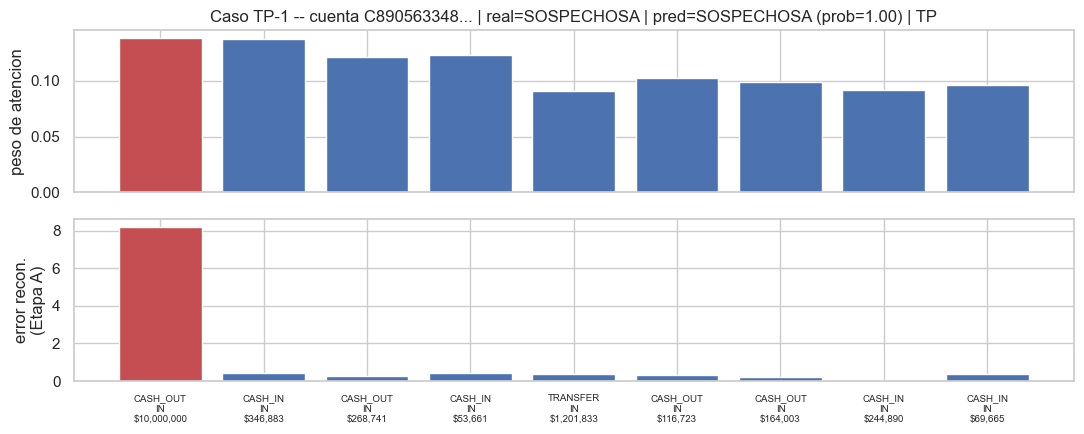

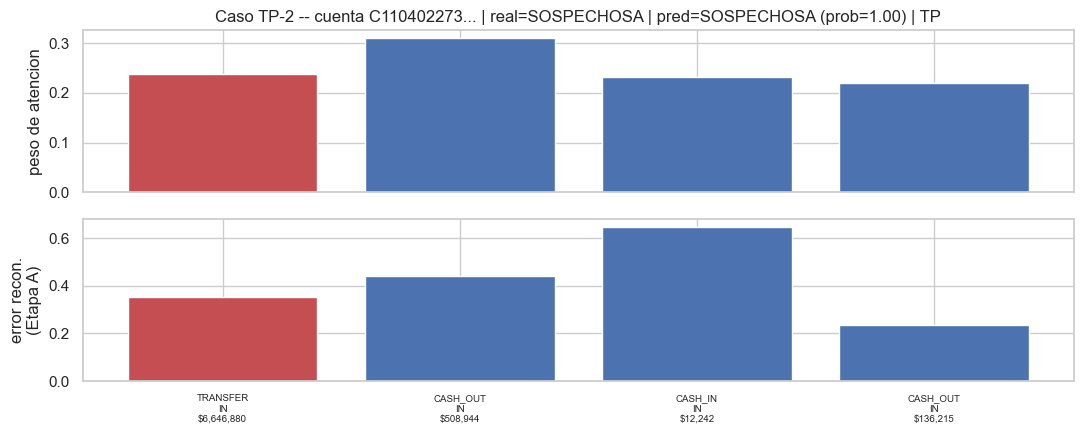

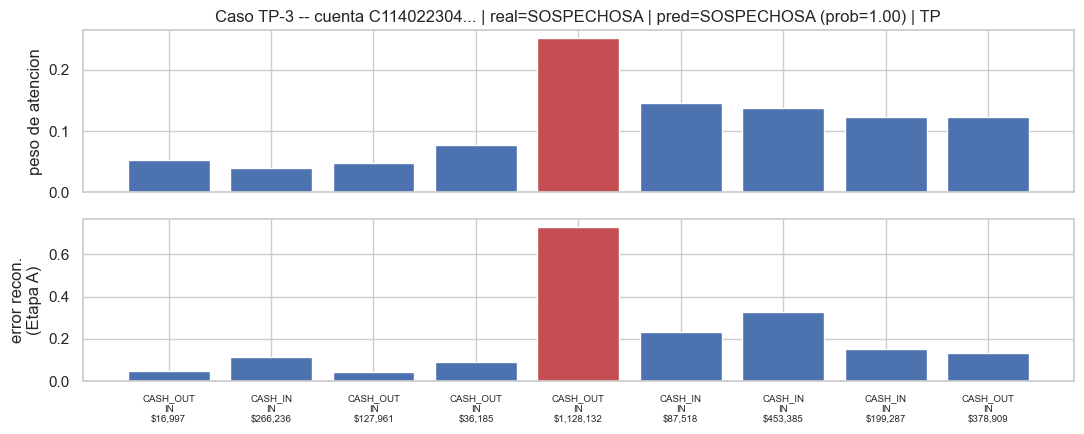

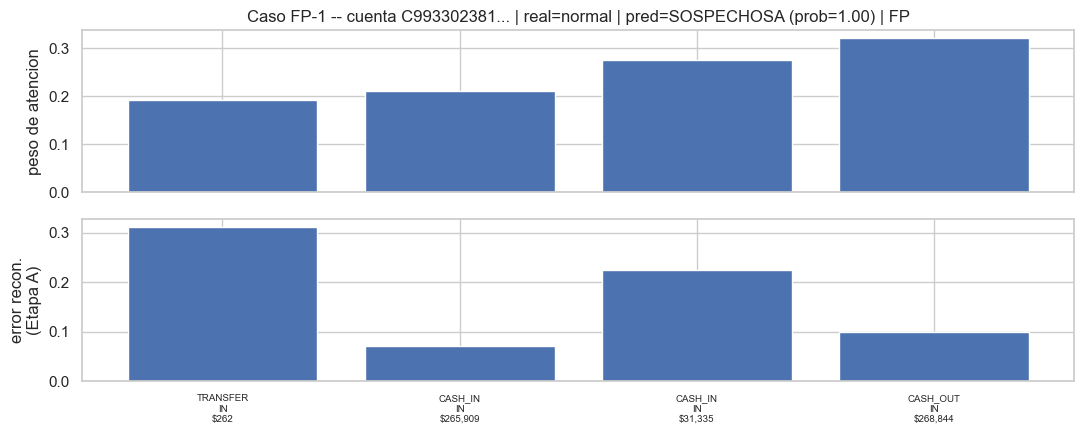

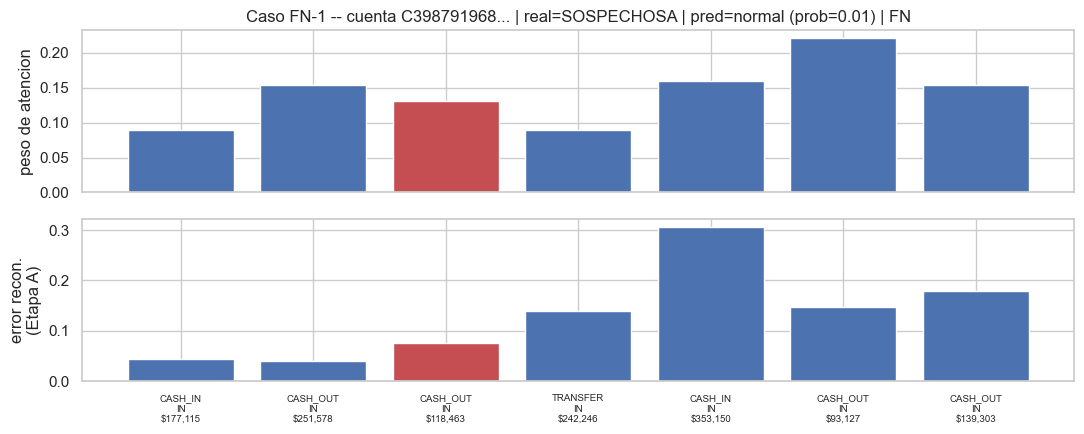

In [6]:
def explain_case(row, ax_attn, ax_err):
    acc = row["account"]
    x, lengths = get_tensors(acc)
    with torch.no_grad():
        score_z = torch.tensor([row["recon_error_z"]], dtype=torch.float32)
        logit, alpha = attn_model.forward_with_attention(x, lengths, score_z)
        err_t, _ = per_timestep_recon_error(x, lengths)
    alpha = alpha.squeeze(0).numpy()[: row["n_events"]]
    err_t = err_t[: row["n_events"]]
    raw = raw_tables[acc]

    labels_x = [f"{TYPE_NAMES[int(t)]}\n{'IN' if d==1 else 'OUT'}\n${a:,.0f}" for t, d, a in zip(raw["type_code"], raw["direction"], raw["amount"])]
    colors = ["#C44E52" if f == 1 else "#4C72B0" for f in raw["isFraud"]]

    ax_attn.bar(range(len(alpha)), alpha, color=colors)
    ax_attn.set_ylabel("peso de atencion")
    ax_attn.set_title(f"Caso {row['caso']} -- cuenta {acc[:10]}... | real={'SOSPECHOSA' if row['has_fraud'] else 'normal'} | pred={'SOSPECHOSA' if row['pred'] else 'normal'} (prob={row['prob']:.2f}) | {row['outcome']}")

    ax_err.bar(range(len(err_t)), err_t, color=colors)
    ax_err.set_ylabel("error recon.\n(Etapa A)")
    ax_err.set_xticks(range(len(labels_x)))
    ax_err.set_xticklabels(labels_x, fontsize=7, rotation=0)

    return alpha, err_t, raw


case_details = {}
for _, row in selected.iterrows():
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 4.5), sharex=True, gridspec_kw={"height_ratios": [1, 1]})
    alpha, err_t, raw = explain_case(row, ax1, ax2)
    plt.tight_layout()
    plt.savefig(DATA_PROCESSED / f"caso_{row['caso']}.png", dpi=110)
    plt.show()
    case_details[row["caso"]] = {"alpha": alpha, "err_t": err_t, "raw": raw, "row": row}

## 4. Interpretacion de cada caso, conectando con tipologias de lavado

Los 5 casos (Seccion 5) se explican en la practica por una sola tipologia: monto atipicamente alto frente al historial de la cuenta. Ninguno activa estructuracion (near_threshold) ni frecuencia inusual (high_freq), aunque ambos indicadores estan implementados. Es consistente con la Seccion 3.1 del Componente 1: PaySim simula el fraude como eventos aislados, sin redes de cuentas ni estructuracion. El sistema queda validado solo para anomalia de monto.

In [7]:
for caso, d in case_details.items():
    row, raw, alpha, err_t = d["row"], d["raw"], d["alpha"], d["err_t"]
    top_attn_idx = int(np.argmax(alpha))
    top_err_idx = int(np.argmax(err_t))
    txn_attn = raw.iloc[top_attn_idx]
    txn_err = raw.iloc[top_err_idx]
    print(f"=== {caso} (cuenta {row['account']}, {row['outcome']}) ===")
    print(f"  prob. Etapa B: {row['prob']:.3f} | score anomalia Etapa A (z): {row['recon_error_z']:.2f} | n_transacciones: {row['n_events']}")
    print(f"  Transaccion con MAYOR peso de atencion (pos {top_attn_idx}): {TYPE_NAMES[int(txn_attn['type_code'])]}, "
          f"{'entrante' if txn_attn['direction']==1 else 'saliente'}, monto=${txn_attn['amount']:,.2f}, "
          f"isFraud={txn_attn['isFraud']}, cerca_umbral={txn_attn['near_threshold']}")
    print(f"  Transaccion con MAYOR error de reconstruccion (pos {top_err_idx}): {TYPE_NAMES[int(txn_err['type_code'])]}, "
          f"{'entrante' if txn_err['direction']==1 else 'saliente'}, monto=${txn_err['amount']:,.2f}, "
          f"isFraud={txn_err['isFraud']}, cerca_umbral={txn_err['near_threshold']}")
    print(f"  ¿Coinciden ambas senales en la misma transaccion?: {top_attn_idx == top_err_idx}")
    print()

=== TP-1 (cuenta C890563348, TP) ===
  prob. Etapa B: 1.000 | score anomalia Etapa A (z): 2.45 | n_transacciones: 9
  Transaccion con MAYOR peso de atencion (pos 0): CASH_OUT, entrante, monto=$10,000,000.00, isFraud=1.0, cerca_umbral=0.0
  Transaccion con MAYOR error de reconstruccion (pos 0): CASH_OUT, entrante, monto=$10,000,000.00, isFraud=1.0, cerca_umbral=0.0
  ¿Coinciden ambas senales en la misma transaccion?: True

=== TP-2 (cuenta C1104022737, TP) ===
  prob. Etapa B: 1.000 | score anomalia Etapa A (z): 0.66 | n_transacciones: 4
  Transaccion con MAYOR peso de atencion (pos 1): CASH_OUT, entrante, monto=$508,943.50, isFraud=0.0, cerca_umbral=0.0
  Transaccion con MAYOR error de reconstruccion (pos 2): CASH_IN, entrante, monto=$12,241.81, isFraud=0.0, cerca_umbral=0.0
  ¿Coinciden ambas senales en la misma transaccion?: False

=== TP-3 (cuenta C114022304, TP) ===
  prob. Etapa B: 1.000 | score anomalia Etapa A (z): 0.17 | n_transacciones: 9
  Transaccion con MAYOR peso de atenci

## 5. Generador de explicacion en lenguaje natural (prototipo para el MVP)

In [8]:
TYPOLOGY_HINTS = {
    "near_threshold": "un monto justo debajo del umbral de reporte obligatorio de $10,000 (posible estructuracion/smurfing)",
    "high_freq": "una concentracion inusual de transacciones en poco tiempo (posible layering/capas)",
    "large_amount": "un monto atipicamente alto respecto al resto del historial de la cuenta",
}


def generate_explanation(caso_id):
    d = case_details[caso_id]
    row, raw, alpha = d["row"], d["raw"], d["alpha"]
    acc = row["account"]
    top_idx = int(np.argmax(alpha))
    txn = raw.iloc[top_idx]
    tipo = TYPE_NAMES[int(txn["type_code"])]
    direccion = "recibio" if txn["direction"] == 1 else "envio"
    veredicto = "sospechosa de lavado de dinero" if row["prob"] >= 0.5 else "dentro de un patron normal"

    razones = []
    if txn["near_threshold"] == 1:
        razones.append(TYPOLOGY_HINTS["near_threshold"])
    if row["n_events"] >= 10:
        razones.append(TYPOLOGY_HINTS["high_freq"])
    if txn["amount"] > raw["amount"].median() * 3:
        razones.append(TYPOLOGY_HINTS["large_amount"])
    razon_txt = "; ".join(razones) if razones else "un patron que se desvia del comportamiento tipico de la cuenta"

    text = (
        f"La cuenta {acc} fue clasificada como {veredicto} con una probabilidad de {row['prob']:.0%} "
        f"(score de anomalia de la Etapa A: {row['recon_error_z']:.1f} desviaciones estandar sobre el promedio de cuentas normales). "
        f"La transaccion que mas peso en esta alerta fue una operacion de tipo {tipo} donde la cuenta {direccion} "
        f"${txn['amount']:,.2f} (transaccion {top_idx+1} de {row['n_events']} en su historial). "
        f"Esta transaccion presenta {razon_txt}."
    )
    return text


for caso_id in case_details:
    print(f"[{caso_id}]")
    print(generate_explanation(caso_id))
    print()

[TP-1]
La cuenta C890563348 fue clasificada como sospechosa de lavado de dinero con una probabilidad de 100% (score de anomalia de la Etapa A: 2.4 desviaciones estandar sobre el promedio de cuentas normales). La transaccion que mas peso en esta alerta fue una operacion de tipo CASH_OUT donde la cuenta recibio $10,000,000.00 (transaccion 1 de 9 en su historial). Esta transaccion presenta un monto atipicamente alto respecto al resto del historial de la cuenta.

[TP-2]
La cuenta C1104022737 fue clasificada como sospechosa de lavado de dinero con una probabilidad de 100% (score de anomalia de la Etapa A: 0.7 desviaciones estandar sobre el promedio de cuentas normales). La transaccion que mas peso en esta alerta fue una operacion de tipo CASH_OUT donde la cuenta recibio $508,943.50 (transaccion 2 de 4 en su historial). Esta transaccion presenta un patron que se desvia del comportamiento tipico de la cuenta.

[TP-3]
La cuenta C114022304 fue clasificada como sospechosa de lavado de dinero con

In [9]:
results_df.to_parquet(DATA_PROCESSED / "test_predictions.parquet", index=False)
selected.to_parquet(DATA_PROCESSED / "selected_cases.parquet", index=False)
print("Guardado: test_predictions.parquet, selected_cases.parquet")

Guardado: test_predictions.parquet, selected_cases.parquet
